In [530]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import csv
import csv as reader

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from scipy import stats

In [532]:
#2.1 Student Performance Dataset

In [534]:
# 1. Load the Data:
# Load the Data: Load the provided Student Performance data in your Jupyter Notebook.

data = pd.read_csv('C:/Users/Charles Inventado/Downloads/Student_Performance.csv')
data

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91
1,4,82,0,4,2,65
2,8,51,1,7,2,45
3,5,52,1,5,2,36
4,7,75,0,8,5,66
...,...,...,...,...,...,...
9995,1,49,1,4,2,23
9996,7,64,1,8,5,58
9997,6,83,1,8,5,74
9998,9,97,1,7,0,95


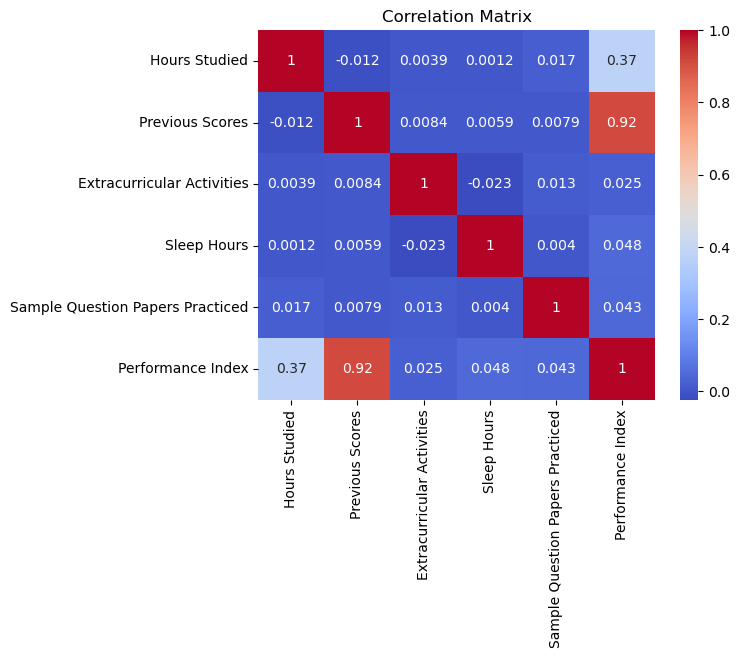

Performance Index                   1.000000
Previous Scores                     0.915189
Hours Studied                       0.373730
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Extracurricular Activities          0.024525
Name: Performance Index, dtype: float64


In [536]:
corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()
print(corr_matrix["Performance Index"].sort_values(ascending=False))

In [538]:
# List of feature columns
feature_cols = ["Hours Studied", "Previous Scores", "Extracurricular Activities", 
                "Sleep Hours", "Sample Question Papers Practiced","Performance Index"]

# Removing outliers from selected feature columns
for col in feature_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

print("New shape after removing outliers:", data.shape)

# No outliers detected on both features and target variable.

New shape after removing outliers: (10000, 6)


In [540]:
# dropping duplicate rows
print(f"Number of rows before removing duplicates: {len(data)}") # Amount of rows before dropping duplicates

transformed_data = data.drop_duplicates()

print(f"Number of rows after removing duplicates: {len(transformed_data)}") # Amount of rows after dropping duplicates

# The dataset contains duplicates

Number of rows before removing duplicates: 10000
Number of rows after removing duplicates: 9873


In [542]:
# Finding empty cells -> There are no empty values
print(transformed_data.isnull().sum())


Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [544]:
#Standarization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_features = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']

# Make an explicit copy to avoid SettingWithCopyWarning
transformed_data = transformed_data.copy()

# Cast the columns to float before transformation
transformed_data[numeric_features] = transformed_data[numeric_features].astype(float)

# Standardize the numeric features
transformed_data.loc[:, numeric_features] = scaler.fit_transform(transformed_data[numeric_features])

print(transformed_data)




      Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0          0.775566         1.706168                           1     1.454025   
1         -0.383205         0.724912                           0    -1.491315   
2          1.161822        -1.064438                           1     0.275889   
3          0.003052        -1.006717                           1    -0.902247   
4          0.775566         0.320865                           0     0.864957   
...             ...              ...                         ...          ...   
9995      -1.541976        -1.179880                           1    -1.491315   
9996       0.775566        -0.314066                           1     0.864957   
9997       0.389309         0.782633                           1     0.864957   
9998       1.548079         1.590727                           1     0.275889   
9999       0.775566         0.263144                           0     0.864957   

      Sample Question Paper

In [546]:
# Encoder for categorical variables
label_encoder = LabelEncoder()

# Use .loc[] to explicitly modify the DataFrame
transformed_data.loc[:, 'Extracurricular Activities'] = label_encoder.fit_transform(transformed_data['Extracurricular Activities'])

print(transformed_data.head())


   Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0       0.775566         1.706168                           1     1.454025   
1      -0.383205         0.724912                           0    -1.491315   
2       1.161822        -1.064438                           1     0.275889   
3       0.003052        -1.006717                           1    -0.902247   
4       0.775566         0.320865                           0     0.864957   

   Sample Question Papers Practiced  Performance Index  
0                         -1.249715                 91  
1                         -0.900925                 65  
2                         -0.900925                 45  
3                         -0.900925                 36  
4                          0.145444                 66  


In [548]:
X = transformed_data.drop('Performance Index', axis = 1)
y = transformed_data['Performance Index']
print(X)
print(y)

      Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0          0.775566         1.706168                           1     1.454025   
1         -0.383205         0.724912                           0    -1.491315   
2          1.161822        -1.064438                           1     0.275889   
3          0.003052        -1.006717                           1    -0.902247   
4          0.775566         0.320865                           0     0.864957   
...             ...              ...                         ...          ...   
9995      -1.541976        -1.179880                           1    -1.491315   
9996       0.775566        -0.314066                           1     0.864957   
9997       0.389309         0.782633                           1     0.864957   
9998       1.548079         1.590727                           1     0.275889   
9999       0.775566         0.263144                           0     0.864957   

      Sample Question Paper

In [550]:
#2. Select a Unique Randomization Seed: 
# Select a Unique Randomization Seed: Select a unique integer that will serve as the seed for your randomization.

# Set the random seed
seed = 33
np.random.seed(seed)

In [552]:
#3. Sample train data
# Sample Train Data: Randomly sample a subset of the data using the seed you have selected; limit the sample to 30.
# Ensure that your sampled data is representative of the population.

In [554]:
X_train_population, X_test_population, y_train_population, y_test_population = train_test_split(X, y, test_size=0.2, random_state=seed)

X_train = X_train_population.sample(n=min(30, len(X_train_population)), random_state=seed) # min to handle cases where there are less than 30 samples.
y_train = y_train_population[X_train.index] # Keep the target corresponding to the sampled features.

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

In [556]:
# Print the shapes to verify
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (30, 5)
y_train shape: (30,)


In [558]:
# Display some of the data
print("\nX_train:")
print(X_train)


X_train:
    Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0        1.548079         0.494028                           0     0.275889   
1        1.548079        -1.468485                           0    -0.902247   
2        1.548079        -1.526206                           0     0.275889   
3        0.775566         0.436307                           0    -0.313179   
4       -0.769462        -0.660392                           0    -0.902247   
5       -0.383205        -0.025461                           0    -0.902247   
6       -0.769462        -1.179880                           1     1.454025   
7        0.775566        -1.699369                           1     0.864957   
8        0.003052        -0.025461                           1     1.454025   
9        0.389309        -1.179880                           1     0.275889   
10      -0.769462         1.013517                           1     0.864957   
11       0.775566        -0.314066        

In [560]:
print("\ny_train:")
print(y_train)


y_train:
0     76
1     37
2     38
3     68
4     37
5     51
6     31
7     31
8     57
9     38
10    69
11    59
12    16
13    79
14    50
15    83
16    65
17    53
18    35
19    33
20    80
21    29
22    59
23    53
24    29
25    49
26    45
27    60
28    32
29    47
Name: Performance Index, dtype: int64


In [562]:
# 4. Weight Update Function: Build a weight update function following the Gradient Descent concept.

# (Optimization: Gradient Descent Stochastic Update Version)
def gradient_descent(X, y, weights, lambda_val, max_iterations, tolerance):
    
    n_samples, n_features = X.shape
    weights = weights.astype(np.float64)
    
    # Add a column (x0) of ones to X to account for the bias term (w0)
    X = np.hstack((np.ones((n_samples, 1)), X))
    
    for iteration in range(max_iterations):
        # Initialize the weight updates to zero
        weight_updates = np.zeros_like(weights)
        
        for i in range(n_samples):
            # Calculate the predicted value y(x)
            multiv_linear_reg = np.dot(X[i], weights)
            
            # Calculate the error (t^(n) - y(x^(n)))
            error = y[i] - multiv_linear_reg 
            
            # Update the weights using the gradient descent formula
            weight_updates += 2 * lambda_val * error * X[i]
            # print(weight_updates) # Just checking if the output is correct compared to doing it manually
        
        # Update the weights
        weights += weight_updates
        weights_history.append(weights.copy())
        
        # Print the weights after each iteration
        print(f"Iteration {iteration + 1}: Weights = {np.round(weights, decimals=4)}")
        
        # Check for convergence
        if np.linalg.norm(weight_updates) < tolerance:
            print(f"\nConverged after {iteration + 1} iterations.")
            break
    
    else:
        print(f"\nReached maximum iterations ({max_iterations}).")
    
    return weights, weights_history

In [564]:
# 5. Display the Values of Weights
# Display the Values of Weights: Print the values of weights at each iteration separated by individual cell.


initial_weights = np.array([1, 50, 25, 100, 75, 125])
learning_rate = 0.01
iterations = 1000
tolerance = 1e-6

# Store the weight history
weights_history = []

# Run gradient descent
trained_weights, weights_history = gradient_descent(X_train, y_train, initial_weights, learning_rate, iterations, tolerance)

print("\nTrained Weights:", np.round(trained_weights, decimals=4))

Iteration 1: Weights = [-0.4849 51.8073 28.0991 75.692  54.3905 69.2744]
Iteration 2: Weights = [ 9.5018 45.3423 24.9369 65.5917 35.041  42.8799]
Iteration 3: Weights = [16.22   37.3393 23.5253 57.4893 21.2866 27.2138]
Iteration 4: Weights = [21.2773 30.3725 22.2975 50.9526 11.8113 17.2633]
Iteration 5: Weights = [25.199  24.8685 21.1928 45.5005  5.4064 10.6936]
Iteration 6: Weights = [28.3555 20.6846 20.2432 40.8714  1.1362  6.2916]
Iteration 7: Weights = [30.9806 17.5547 19.4678 36.8904 -1.6605  3.3362]
Iteration 8: Weights = [33.2225 15.2259 18.8598 33.4314 -3.4411  1.3644]
Iteration 9: Weights = [35.1768 13.4921 18.3975 30.3993 -4.5215  0.0671]
Iteration 10: Weights = [36.9067 12.1953 18.0547 27.7208 -5.1212 -0.7669]
Iteration 11: Weights = [38.4549 11.2179 17.806  25.3386 -5.3929 -1.2826]
Iteration 12: Weights = [39.8514 10.4737 17.6295 23.2075 -5.4437 -1.5808]
Iteration 13: Weights = [41.1181  9.9002 17.507  21.2914 -5.3484 -1.7311]
Iteration 14: Weights = [42.2718  9.452  17.424

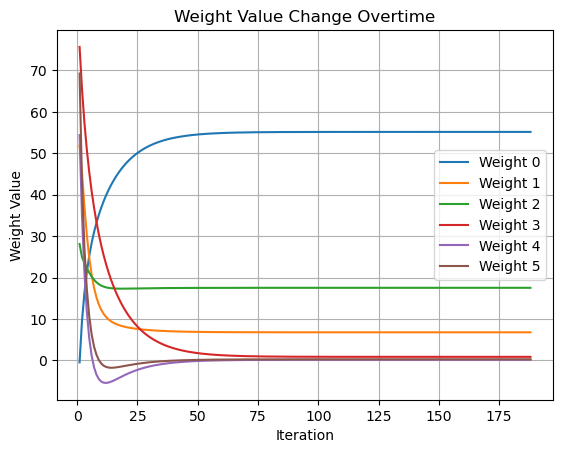

In [566]:
# 6 Plot the Value of Weights
# Plot the Value of Weights: Display a line chart showing the variation of weight values per iteration.
# Per each weight, show an individual line chart of values against iteration.

# Plotting the weights over iterations
num_weights = trained_weights.shape[0]  # Number of weights (including bias)
iterations_range = range(1, len(weights_history) + 1) # Iteration numbers

for i in range(num_weights):
    weight_values = [weights[i] for weights in weights_history]
    plt.plot(iterations_range, weight_values, label=f"Weight {i}")

plt.xlabel("Iteration")
plt.ylabel("Weight Value")
plt.title("Weight Value Change Overtime")
plt.legend()
plt.grid(True)
plt.show()

In [568]:
# 7. Build a Function for the Final Regression Model
# Build a Function for the Final Regression Model: Create a function using the final regression model after all your iterations. 
# Display the mathematical expression with all the final weights values multiplied by the input variables.

In [570]:
def Multivariate_Linear_Regression(X, weights):
    n_samples, n_features = X.shape

    # Add a column (x0) of ones to X to account for the bias term (w0)
    X = np.hstack((np.ones((n_samples, 1)), X))
    
    y_preds = []  # Initialize an empty list to store predictions
    
    for i in range(n_samples):
        # Calculate the predicted value y(x)
        y_pred = np.dot(X[i], weights)
        y_preds.append(y_pred) # Append the prediction to the list
        
    return np.array(y_preds) 

In [572]:
# 8. Sample Test Data -> limit to 30
# Sample Test Data: From the remainder of the original dataset, 
# randomly sample another set of 30 observations NOT present in your training sample.

X_test = X_test_population.sample(n=min(30, len(X_test_population)), random_state=seed)
y_test = y_test_population[X_test.index]

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Print the shapes to verify
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (30, 5)
y_test shape: (30,)


In [574]:
# Display some of the data
print("\nX_test head:")
print(X_test)


X_test head:
    Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0        1.161822        -1.641648                           1    -0.902247   
1        1.548079         1.359843                           0    -0.313179   
2        1.548079        -0.718113                           1    -1.491315   
3        1.161822         1.590727                           1    -0.902247   
4       -1.541976        -0.544950                           1     0.275889   
5        0.003052         0.955796                           1     0.275889   
6       -1.155719         1.648448                           1     0.275889   
7        0.775566         1.244401                           0    -1.491315   
8        1.548079         0.378586                           0     0.864957   
9        0.003052        -0.833555                           1    -1.491315   
10       0.389309        -1.699369                           1    -1.491315   
11      -0.769462         1.648448    

In [576]:
print("\ny_test head:")
print(y_test)


y_test head:
0     33
1     87
2     52
3     91
4     39
5     73
6     74
7     82
8     77
9     37
10    28
11    79
12    33
13    65
14    17
15    86
16    61
17    45
18    47
19    55
20    71
21    75
22    53
23    65
24    63
25    61
26    80
27    64
28    33
29    72
Name: Performance Index, dtype: int64


In [578]:
# 9. Use the Regression Function for Prediction
# Use the Regression Function for Prediction:
# Use your built linear regression function to predict for the Target Variable in your test set.


# Prediction for the Training Data
y_pred_train = Multivariate_Linear_Regression(X_train, trained_weights)

print("Training Data Prediction")
for i in range(len(y_pred_train)):
    print(f"Training Record {i} Prediction of y(x): = {np.round(y_pred_train[i], decimals=4)}")

Training Data Prediction
Training Record 0 Prediction of y(x): = 74.3131
Training Record 1 Prediction of y(x): = 39.4739
Training Record 2 Prediction of y(x): = 39.1767
Training Record 3 Prediction of y(x): = 67.7079
Training Record 4 Prediction of y(x): = 38.3704
Training Record 5 Prediction of y(x): = 52.2044
Training Record 6 Prediction of y(x): = 30.3059
Training Record 7 Prediction of y(x): = 31.7628
Training Record 8 Prediction of y(x): = 55.6839
Training Record 9 Prediction of y(x): = 38.2469
Training Record 10 Prediction of y(x): = 68.5645
Training Record 11 Prediction of y(x): = 55.9478
Training Record 12 Prediction of y(x): = 15.0168
Training Record 13 Prediction of y(x): = 80.73
Training Record 14 Prediction of y(x): = 51.2835
Training Record 15 Prediction of y(x): = 82.5498
Training Record 16 Prediction of y(x): = 67.3129
Training Record 17 Prediction of y(x): = 52.2005
Training Record 18 Prediction of y(x): = 34.1737
Training Record 19 Prediction of y(x): = 30.3705
Trainin

In [580]:
# Prediction for the Test Data
y_pred_test = Multivariate_Linear_Regression(X_test, trained_weights)

print("Test Data Prediction")
for i in range(len(y_pred_test)):
    print(f"Test Record {i} Prediction of y(x): = {np.round(y_pred_test[i], decimals=4)}")

Test Data Prediction
Test Record 0 Prediction of y(x): = 34.6769
Test Record 1 Prediction of y(x): = 89.1288
Test Record 2 Prediction of y(x): = 54.012
Test Record 3 Prediction of y(x): = 91.856
Test Record 4 Prediction of y(x): = 36.3714
Test Record 5 Prediction of y(x): = 72.9661
Test Record 6 Prediction of y(x): = 76.7159
Test Record 7 Prediction of y(x): = 81.8666
Test Record 8 Prediction of y(x): = 72.2025
Test Record 9 Prediction of y(x): = 41.6049
Test Record 10 Prediction of y(x): = 29.0502
Test Record 11 Prediction of y(x): = 79.69
Test Record 12 Prediction of y(x): = 34.348
Test Record 13 Prediction of y(x): = 65.4187
Test Record 14 Prediction of y(x): = 18.2556
Test Record 15 Prediction of y(x): = 84.5403
Test Record 16 Prediction of y(x): = 63.7819
Test Record 17 Prediction of y(x): = 49.9387
Test Record 18 Prediction of y(x): = 49.9489
Test Record 19 Prediction of y(x): = 53.3945
Test Record 20 Prediction of y(x): = 69.7635
Test Record 21 Prediction of y(x): = 76.0633
Test

In [582]:
# 10. Calculate for Errors
# Calculate for Errors: Calculate for the overall error between your model’s prediction and the actual values in the test set.


def evaluate_model(y_data, y_pred, model_name):
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name}")
    print(f"     Mean Squared Error (MSE): {mse:.4f}")
    print(f"     Mean Squared Error (MSE): {rmse:.4f}")
    print(f"     R-squared (R2): {r2:.4f}")

In [584]:
print("Evaluating Model using Training Data")
evaluate_model(y_train, y_pred_train, "Multivariate Linear Regression")

Evaluating Model using Training Data
Multivariate Linear Regression
     Mean Squared Error (MSE): 662.4281
     Mean Squared Error (MSE): 25.7377
     R-squared (R2): -0.7442


In [586]:
print("Evaluating Model using Test Data")
evaluate_model(y_test, y_pred_test, "Multivariate Linear Regression")

Evaluating Model using Test Data
Multivariate Linear Regression
     Mean Squared Error (MSE): 5.4373
     Mean Squared Error (MSE): 2.3318
     R-squared (R2): 0.9857


In [588]:
################### PART 2 ################### 

In [621]:
#2.2 Breast Cancer Dataset (Assignment)

In [623]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [625]:
# Load the Data: 
data = load_breast_cancer()
X = data.data
y =  data.target

In [627]:
# 1. Select a Unique Randomization Seed: Select a unique integer that will serve as the seed for your randomization.
seed = 33
np.random.seed(seed)

In [629]:
# 2. Sample Train Data: Randomly sample a subset of the data using the seed you have selected; limit the sample to 30. 
# Ensure that your sampled data is representative of the population.

def normalize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    return (X - mean) / std

# Sample and train data (30 samples)
indices = np.random.choice(range(len(X)), 30, replace=False)
X_train = X[indices]
y_train = y[indices]

# Normalize training data
X_train_normalized = normalize(X_train)

In [631]:
# 3. Weight Update Function: Build a weight update function following the Gradient Descent concept.
#=====================================================================================================================================================#
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(y, y_pred):
    return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

def gradient_descent(X, y, lr=0.01, epochs=100):
    m, n = X.shape
    weights = np.zeros(n)
    bias = 0
    losses = []
    weight_history = np.zeros((epochs, n))  # Store weights at each iteration

    for epoch in range(epochs):
        linear_model = np.dot(X, weights) + bias
        y_pred = sigmoid(linear_model)

        dw = (1 / m) * np.dot(X.T, (y_pred - y))
        db = (1 / m) * np.sum(y_pred - y)

        weights -= lr * dw
        bias -= lr * db

        loss = compute_loss(y, y_pred)
        losses.append(loss)
        weight_history[epoch] = weights  # Store weights properly

        if epoch % 10 == 0:  # Print every 10 epochs to avoid spam
            print(f"Epoch {epoch+1}: Weights: {weights}, Bias: {bias}, Loss: {loss:.4f}")

    return weights, bias, losses, weight_history
#=====================================================================================================================================================#

In [633]:
# 4. Display the Values of Weights: Print the values of weights at each iteration separated by individual cell.

# Train the model
final_weights, final_bias, loss_history, weight_history = gradient_descent(X_train_normalized, y_train)

Epoch 1: Weights: [-2.45893993e-03 -1.74833805e-03 -2.54339369e-03 -2.50660114e-03
 -1.82118847e-03 -2.21791336e-03 -2.79993335e-03 -3.50332248e-03
 -1.86225012e-03 -3.83292652e-04 -2.45647525e-03  6.55895186e-04
 -2.18893443e-03 -2.71996848e-03  1.15853058e-03 -4.68365273e-04
 -5.12768868e-04 -6.31346417e-04  1.25113805e-03  1.85962181e-05
 -3.27594545e-03 -2.36692044e-03 -3.37161725e-03 -3.18506828e-03
 -2.99862841e-03 -3.26652659e-03 -3.31238410e-03 -3.66679401e-03
 -3.23711013e-03 -2.62987992e-03], Bias: 0.002, Loss: 0.6931
Epoch 11: Weights: [-0.02286345 -0.01742761 -0.02363286 -0.02333979 -0.01766816 -0.02010301
 -0.02584404 -0.03318319 -0.01793123 -0.00335026 -0.02286354  0.00712959
 -0.02010155 -0.02547224  0.01140328 -0.00276691 -0.00311469 -0.0041886
  0.01265624  0.00171371 -0.03113506 -0.02361643 -0.03205657 -0.03016068
 -0.02989191 -0.03122528 -0.03134812 -0.03494633 -0.03233558 -0.02511062], Bias: 0.021701995817177085, Loss: 0.5550
Epoch 21: Weights: [-0.03771    -0.03056

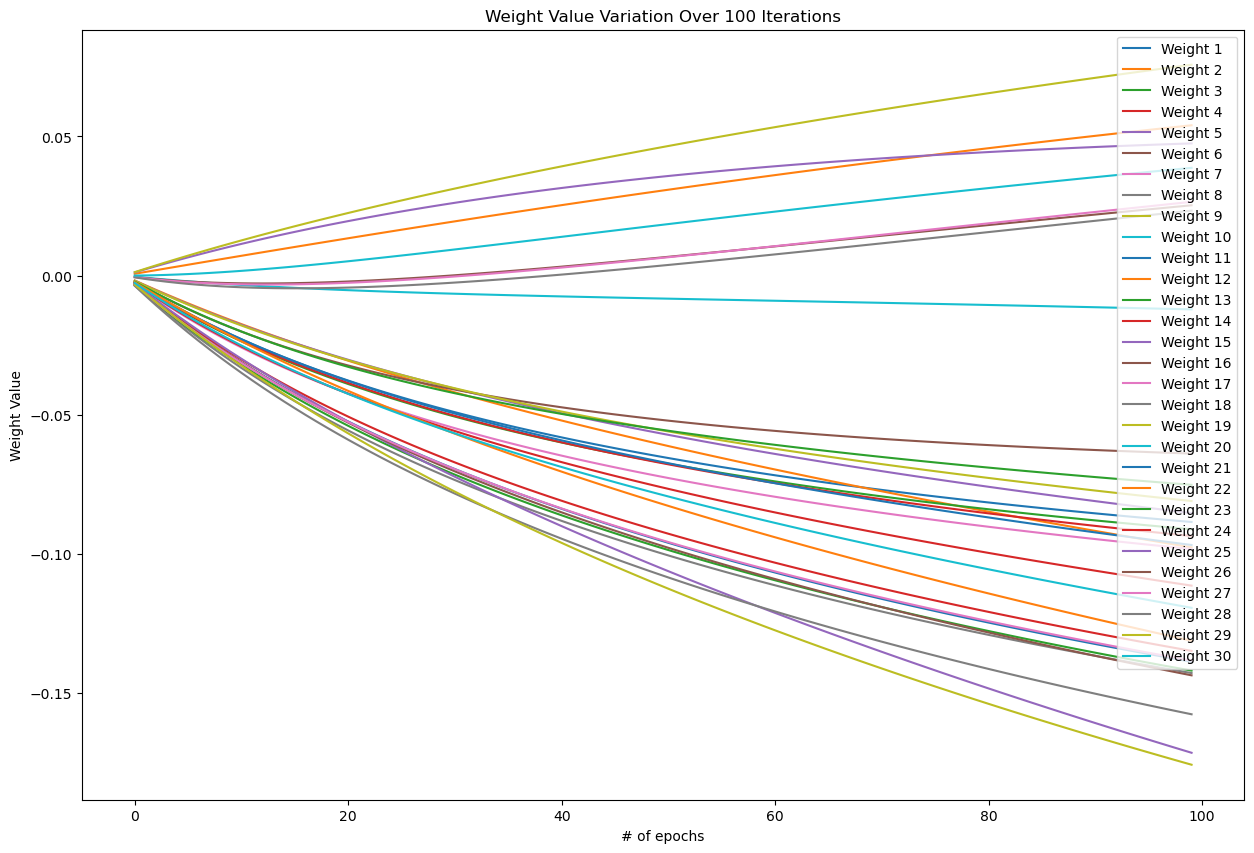

In [635]:
# 5. Plot the Value of Weights: Display a line chart showing the variation of weight values per iteration.
# Per each weight, show an individual line chart of values against iteration.


plt.figure(figsize=(15, 10))
for i in range(X_train.shape[1]):  
    plt.plot(range(len(weight_history)), weight_history[:, i], label=f"Weight {i+1}")

plt.xlabel("# of epochs")
plt.ylabel("Weight Value")
plt.title("Weight Value Variation Over 100 Iterations")
plt.legend()
plt.show()

In [637]:
# 6. Build a Function for the Final Regression Model: Create a function using the final regression model after all your iterations. 
# Display the mathematical expression with all the final weights values multiplied by the input variables.

#=====================================================================================================================================================#
def Logistic_Regression_Model(X, weights):
    n_samples, n_features = X.shape

    # Add a column of ones to X for the bias term (w0)
    X = np.hstack([np.ones((n_samples, 1)), X])

    # Initialize an empty list to store predictions
    y_preds = []  
    
    for i in range(n_samples):
        x_i = X[i]
        # Compute the predicted probability
        z = np.dot(weights, x_i)
        probability = sigmoid(z)
        y_preds.append(probability) # Append the prediction to the list
        
    return np.array(y_preds)  
#=====================================================================================================================================================#

In [639]:
# 7. Sample Test Data: From the remainder of the original dataset,
# randomly sample another set of 30 observations NOT present in your training sample.

# 7. Create final regression function
def predict(X, weights, bias):
    return sigmoid(np.dot(X, weights) + bias)

In [641]:
# 7. Sample Test Data: From the remainder of the original dataset,
# randomly sample another set of 30 observations NOT present in your training sample.

remaining_indices = list(set(range(len(X))) - set(indices))
test_indices = np.random.choice(remaining_indices, 30, replace=False)
X_test = X[test_indices]
y_test = y[test_indices]

# Normalize test data
X_test_normalized = normalize(X_test)

In [643]:
X_test_normalized

array([[-8.35730696e-01, -3.02912084e-01, -8.55304328e-01,
        -8.32956623e-01, -7.05525117e-01, -7.40763819e-01,
        -8.69522138e-01, -9.90932593e-01, -7.14737679e-01,
        -1.18437806e-01, -8.84819763e-01, -3.00680026e-01,
        -8.89875226e-01, -8.28777374e-01,  2.66150729e-01,
        -7.02131550e-01, -1.06357332e+00, -1.05782051e+00,
         1.24447974e-01, -2.87829209e-01, -7.43528815e-01,
         6.99767291e-02, -7.79901918e-01, -7.37402713e-01,
         1.59936840e-01, -5.89766254e-01, -8.93631112e-01,
        -8.83715799e-01,  1.47418113e-01,  2.72372575e-01],
       [-3.02133350e-01, -1.37515470e-01, -3.44222185e-01,
        -3.83772985e-01, -4.89961394e-01, -6.47238468e-01,
        -8.10920338e-01, -6.66670980e-01, -7.14737679e-01,
        -8.73352997e-01, -5.12579704e-01,  8.79337088e-01,
        -4.92686062e-01, -5.16130105e-01, -3.01667536e-01,
        -7.02658775e-01, -1.06440306e+00, -8.17202509e-01,
         1.70225450e-01, -6.19552308e-01, -3.33547562e-

In [645]:
# 8. Use the Regression Function for Prediction:
# Use your built linear regression function to predict for the Target Variable in your test set.

y_pred_test = predict(X_test_normalized, final_weights, final_bias)

In [647]:
y_pred_test

array([0.82586434, 0.80452847, 0.5207526 , 0.78576204, 0.09335819,
       0.26524861, 0.90916169, 0.8575429 , 0.06672604, 0.86177175,
       0.80593525, 0.80930335, 0.21266081, 0.00415074, 0.75256319,
       0.72701474, 0.56300554, 0.17886736, 0.78358417, 0.61990663,
       0.83721524, 0.77881325, 0.873437  , 0.04027708, 0.87425922,
       0.92743386, 0.39432416, 0.01772116, 0.19415278, 0.85278597])

In [649]:
# 9. Calculate for Errors: Calculate for the overall error
# between your model’s prediction and the actual values in the test set.

y_pred_labels = (y_pred_test >= 0.5).astype(int)
error = np.mean(y_pred_labels != y_test)

print(f"Final Model Error on Test Data: {error:.4f}")


Final Model Error on Test Data: 0.1000
